(sec-sgate)=
# S Gate and S$^\dagger$ Gate

We shall call $S$ and $S^\dagger$ gates SGate and SdgGate, respectively.

[API References: SGate](https://qiskit.org/documentation/stubs/qiskit.circuit.library.SGate.html#qiskit.circuit.library.SGate)  
[API References: SdgGate](https://qiskit.org/documentation/stubs/qiskit.circuit.library.SdgGate.html#qiskit.circuit.library.SdgGate)  

## Definition

**Transformation**
$$
\begin{aligned}
S |0\rangle &= |0\rangle, \qquad S |1\rangle = i|1\rangle \\   
S^\dagger |0\rangle &= |0\rangle, \qquad S^\dagger |1\rangle = -i|1\rangle
\end{aligned}
$$(SGate)



**Matrix expression**

$$
S \doteq \begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix}, \quad S^\dagger \doteq \begin{bmatrix} 1 & 0 \\ 0 & -i \end{bmatrix}
$$(Sgate-matrix)

**U gate expression**

$$
S = U\left(0,0,\frac{\pi}{2}\right), \quad S^\dagger = U\left(0,0,-\frac{\pi}{2}\right)
$$
(Sgate-U)

**R gate expression**

$$
S = e^{i\pi/4} R_z (\pi/2), \quad S^\dagger = e^{-i\pi/4} R_z (-\pi/2)
$$

The qiskit circuit code symbols are `s`  and `sdg`, respectively. They appear in quantum circuits as

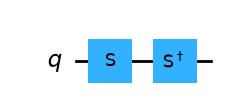

In [1]:
from qiskit import QuantumCircuit
qc=QuantumCircuit(1)
qc.s(0)
qc.sdg(0)
qc.draw('mpl')

or

In [2]:
qc.draw()

┌───┐┌─────┐
q: ┤ S ├┤ Sdg ├
   └───┘└─────┘

## Acting on a superposition state

When SGate and SdgGate are applied to a super position state the coefficient to $|0\rangle$ remains the same but that of $|1\rangle$ gets additional phase factor.  That is

$$
S \left (c_0 |0\rangle + c_1 |1\rangle\right) = c_0 |0\rangle + i c_1 |1\rangle 
$$(S-on-superpos)

$$
S^\dagger \left (c_0 |0\rangle + c_1 |1\rangle\right) = c_0 |0\rangle - i c_1 |1\rangle 
$$(Sdg-on-superpos)


In Bloch sphere representation,

$$
S \left( \cos(\theta/2)|0\rangle + \sin(\theta/2) e^{i\phi}|1\rangle\right) = \cos(\theta/2) |0\rangle + \sin(\theta/2) e^{i (\phi+\pi/2)} |1\rangle
$$

$$
S^\dagger \left( \cos(\theta/2)|0\rangle + \sin(\theta/2) e^{i\phi}|1\rangle\right) = \cos(\theta/2) |0\rangle + \sin(\theta/2) e^{i (\phi-\pi/2)} |1\rangle
$$

This suggests that the Bloch vector rotates around $z$ axis by $\pm\pi/2$.
Notice that the relative phase changes by $e^{\pm i\pi/2} = \pm i$.  Recall that $Z$ changes the relative phase by $e^{i \pi} = -1$. Further notice that $(e^{\pm i \pi/2})^2 = e^{i \pi}$.  Hence, $S^2 = (S^\dagger)^2 = Z$.  Because of this relation,  $S$ is sometimes expressed as $\sqrt{Z}$ or $Z^{1/2}$ and $S^\dagger = Z^{-1/2}$.

Setting $c_0=c_1=\frac{1}{\sqrt{2}}$, we find basis transformation

$$
S|+\rangle = |L\rangle, \quad S|-\rangle = |R\rangle
$$(Sgate-fwd)

$$
S^\dagger|+\rangle = |R\rangle, \quad S^\dagger|-\rangle = |L\rangle
$$(SdgGate-fwd)

Since $S$ is unitary $S S^\dagger = I$ and thus $S^{-1}=S^\dagger$ and $(S^\dagger)^{-1} = S$.  Now the inverse of {eq}`Sgate-fwd` and `SdgGate- fwd` are

$$
S^\dagger |L\rangle = |+\rangle, \quad S^\dagger|R\rangle = |-\rangle
$$(Sgate-inv)

$$
S|L\rangle = |-\rangle, \quad S|R\rangle = |+\rangle
$$(SdgGate-inv)


Combining HGate and SGate, we can transform the computational basis $\{|0\rangle, |1\rangle\}$ to $\{|L\rangle, |R\rangle\}$ by $S \cdot H$ and its inverse is $H \cdot S^\dagger$.  Now, we know we can move from one basis to another by $H$, $S$, and $S \cdot H$. 


---
**Qiskit Example** {numref}`%s <sec-sgate>`.1&nbsp; We demonstrate the above basis set transformation using Qiskit.  First, we construct a quantum circuit corresponding to the following transformation

$$
|0\rangle \xrightarrow{H} |+\rangle \xrightarrow{S} |L\rangle \xrightarrow{S^\dagger} |+\rangle \xrightarrow{H} |0\rangle
$$

Notice that the whole operation can be written as $H \cdot S^\dagger \cdot S \cdot H |0\rangle$ it can be simplified as

$$
H \cdot S^\dagger \cdot S \cdot H |0\rangle = H \cdot (S^\dagger \cdot S) \cdot H = H \cdot I \cdot H = H^2 = I
$$

Hence, the whole operation does nothing at all.  In order to avoid unnecessary computation like this, we need to understand the properties of gates.  You will surprise that a long circuit can be significantly shortened by contracting gates.

In [3]:
%%capture
from qiskit import *
from qiskit.visualization import visualize_transition

qc=QuantumCircuit(1)

qc.h(0)
qc.s(0)
qc.sdg(0)
qc.h(0)

movie=visualize_transition(qc,fpg=10, spg=1)

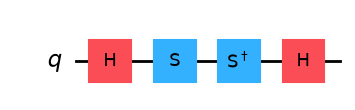

In [4]:
qc.draw('mpl')

In [5]:
movie

## Additional useful Properties

$S \cdot, S = S^\dagger \cdot S^\dagger = Z$ implies that
1. $S = Z \cdot S^\dagger = S^\dagger \cdot Z, \quad S^\dagger = Z \cdot S = S  \cdot Z$.
2. $Z = S \cdot Z \cdot  S^\dagger = S^\dagger \cdot Z \cdot S$
3. $S = Z \cdot S \cdot Z, \quad S^\dagger = Z \cdot S^\dagger \cdot Z$.


---
Last modified: 08/31/2022